# Stage 2: Graph-Based Manga Recommendation Baselines

Load the SQLite data, build the graph tables, and run the Stage 2 heuristic recommenders.


## Environment

Run the notebook from the repo against `data/db/manga.db`.
The requirements.txt should have everything needed.

In [70]:
# notebook setup
# this points the notebook at the repo, database, and example user i use later

from pathlib import Path
import ast
import math
import sqlite3
from collections import Counter

import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)

REPO_ROOT = Path('C:/Users/avrey/dev/shelf')
DB_PATH = REPO_ROOT / 'data' / 'db' / 'manga.db'
EXAMPLE_USER_ID = 'avreylavelle'

print(f'Repo root: {REPO_ROOT}')
print(f'Database path: {DB_PATH}')
print(f'Database size (MB): {DB_PATH.stat().st_size / 1024**2:.1f}')
print(f'Example user for heuristic previews: {EXAMPLE_USER_ID}')

Repo root: C:\Users\avrey\dev\shelf
Database path: C:\Users\avrey\dev\shelf\data\db\manga.db
Database size (MB): 202.8
Example user for heuristic previews: avreylavelle


## Graph Schema

Build user, manga, genre, theme, and author nodes with user-item and manga-metadata edges.


In [71]:
# check what is in the database
# i start with the table counts so i know the data loaded correctly

with sqlite3.connect(DB_PATH) as conn:
    table_names = pd.read_sql_query(
        "SELECT name FROM sqlite_master WHERE type IN ('table', 'view') ORDER BY name",
        conn,
    )['name'].tolist()

    table_counts = []
    for name in table_names:
        count = conn.execute(f'SELECT COUNT(*) FROM {name}').fetchone()[0]
        table_counts.append({'table_name': name, 'row_count': count})

    table_counts_df = pd.DataFrame(table_counts).sort_values('row_count', ascending=False)

display(table_counts_df)

,table_name,row_count
1,manga_core,90080
3,manga_merged,90080
0,manga_cleaned,77360
4,manga_stats,77348
2,manga_map,42532
7,user_events,261
8,user_ratings,87
11,user_requests,50
9,user_reading_list,20
12,users,8


In [72]:
# load the main tables
# these are the user, interaction, and manga tables used to build the graph

with sqlite3.connect(DB_PATH) as conn:
    users_df = pd.read_sql_query('SELECT * FROM users', conn)
    ratings_df = pd.read_sql_query('SELECT * FROM user_ratings', conn)
    reading_df = pd.read_sql_query('SELECT * FROM user_reading_list', conn)
    dnr_df = pd.read_sql_query('SELECT * FROM user_dnr', conn)
    manga_df = pd.read_sql_query(
        '''
        SELECT
            core.id AS manga_id,
            core.title_name,
            core.english_name,
            core.japanese_name,
            core.item_type,
            core.authors,
            core.genres,
            core.themes,
            core.status,
            core.publishing_date,
            core.demographic,
            map.mal_id,
            stats.score,
            stats.popularity,
            stats.members,
            stats.favorited
        FROM manga_core AS core
        LEFT JOIN manga_map AS map ON map.mangadex_id = core.id
        LEFT JOIN manga_stats AS stats ON stats.mal_id = map.mal_id
        ''',
        conn,
    )

print('users_df:', users_df.shape)
print('ratings_df:', ratings_df.shape)
print('reading_df:', reading_df.shape)
print('dnr_df:', dnr_df.shape)
print('manga_df:', manga_df.shape)

users_df: (8, 13)
ratings_df: (87, 9)
reading_df: (20, 7)
dnr_df: (6, 6)
manga_df: (90080, 16)


In [73]:
# quick data preview
# this is just a sanity check before i start building edges and features

preview_frames = {
    'users': users_df.head(3),
    'ratings': ratings_df.head(3),
    'reading_list': reading_df.head(3),
    'dnr': dnr_df.head(3),
    'manga': manga_df.head(3),
}

for name, frame in preview_frames.items():
    print(f'\n{name}')
    display(frame)


users


,username,age,gender,preferred_genres,preferred_themes,password_hash,language,ui_prefs,signal_genres,signal_themes,blacklist_genres,blacklist_themes,is_admin
0,avreylavelle,21.0,Male,"{'Action': 6, 'Adventure': 5, 'Isekai': 3, 'Cr...",{},scrypt:32768:8:1$TDUhqgSvto9YuPXr$d28b664b4ee8...,English,"{'ratings_sort': 'rating_desc', 'dnr_sort': 'c...","{'Historical': 0.03638676844783715, 'Action': ...","{'Demons': 0.12119309262166407, 'Martial Arts'...",{},{},1
1,isaacmeyer,22.0,Male,{},{},scrypt:32768:8:1$SEcO6EHZUnV8gpaZ$e722de7277e1...,English,"{'ratings_sort': 'rating_desc', 'recs_mode': '...","{'Action': 0.2075824190295587, 'Romance': 0.00...","{'Demons': 0.05452400492408699, 'Martial Arts'...",{},{},0
2,Jnance142,22.0,Male,{},{},scrypt:32768:8:1$nrOk2MKEZTKR9cJi$dfb730d959b1...,NaN,NaN,NaN,NaN,NaN,NaN,0



ratings


,user_id,manga_id,rating,created_at,recommended_by_us,finished_reading,mal_id,mdex_id,canonical_id
0,isaacmeyer,3x3 Eyes,2.0,2026-01-25 21:30:05,0,0,662,95a297a4-e8b5-4ac1-bcdc-d4ed160b8945,95a297a4-e8b5-4ac1-bcdc-d4ed160b8945
1,isaacmeyer,"A-Rank Party wo Ridatsu shita Ore wa, Moto Osh...",4.2,2026-01-25 21:30:05,0,0,138373,76e89e4a-59da-4f6a-8b8a-9022f6b4910e,76e89e4a-59da-4f6a-8b8a-9022f6b4910e
2,isaacmeyer,Ao no ExorcistBlue Exorcist,3.9,2026-01-25 21:30:05,0,0,13492,49e11a2c-5ca8-47c9-9d1b-39863b96cecf,49e11a2c-5ca8-47c9-9d1b-39863b96cecf



reading_list


,user_id,manga_id,created_at,status,mal_id,mdex_id,canonical_id
0,bossitronio,Monster,2026-01-29 05:25:17,Plan to Read,1,d9e30523-9d65-469e-92a2-302995770950,d9e30523-9d65-469e-92a2-302995770950
1,bossitronio,Mushoku Tensei: Isekai Ittara Honki DasuMushok...,2026-01-29 05:25:31,Plan to Read,70259,bd6d0982-0091-4945-ad70-c028ed3c0917,bd6d0982-0091-4945-ad70-c028ed3c0917
2,bossitronio,Kingdom,2026-01-29 05:27:34,Plan to Read,16765,077a3fed-1634-424f-be7a-9a96b7f07b78,077a3fed-1634-424f-be7a-9a96b7f07b78



dnr


,user_id,manga_id,created_at,mal_id,mdex_id,canonical_id
0,isaacmeyer,One Piece,2026-01-28 02:07:32,13,a1c7c817-4e59-43b7-9365-09675a149a6f,a1c7c817-4e59-43b7-9365-09675a149a6f
1,isaacmeyer,JoJo no Kimyou na Bouken Part 7: Steel Ball Ru...,2026-01-28 02:08:16,1706,1044287a-73df-48d0-b0b2-5327f32dd651,1044287a-73df-48d0-b0b2-5327f32dd651
2,avreylavelle,1044287a-73df-48d0-b0b2-5327f32dd651,2026-01-30 05:15:52,1706,1044287a-73df-48d0-b0b2-5327f32dd651,1044287a-73df-48d0-b0b2-5327f32dd651



manga


,manga_id,title_name,english_name,japanese_name,item_type,authors,genres,themes,status,publishing_date,demographic,mal_id,score,popularity,members,favorited
0,6b2617f4-4a3c-4d26-a6d5-9fe0ccae9dcd,Lucky Me,Lucky Me,Lucky Me,Manga,['Edward Sam'],['Slice of Life'],['School Life'],ongoing,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0c040315-355c-4a38-b586-d7ad021ff914,Tonari no Danshi,Tonari no Danshi,Tonari no Danshi,Manga,['Yokoyama Mayumi'],"['Romance', 'Comedy']",['School Life'],completed,NaN,shoujo,11310.0,7.15,4864.0,4735.0,13.0
2,4f48babf-34d6-4e47-b1bd-c3bc6e47249a,King Of Kung Fu,King Of Kung Fu,King Of Kung Fu,Manhua,[],"['Action', 'Sports', 'Drama']",['Martial Arts'],ongoing,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [74]:
# parsing helpers
# these clean list fields and turn manga metadata into graph edge tables

def normalize_list_items(values):
    return [
        text
        for text in (str(item).strip() for item in values)
        if text and text.lower() != 'none'
    ]


def parse_literal_list(value):
    if value is None:
        return []
    if isinstance(value, list):
        return normalize_list_items(value)

    text = str(value).strip()
    if not text or text.lower() in {'none', 'nan'} or text == '[]':
        return []

    try:
        parsed = ast.literal_eval(text)
    except (SyntaxError, ValueError):
        parsed = None

    if isinstance(parsed, (list, tuple, set)):
        return normalize_list_items(parsed)

    return [part.strip() for part in text.split(',') if part.strip()]


def pick_manga_id(row):
    for column in ('canonical_id', 'mdex_id', 'manga_id'):
        value = row.get(column)
        if pd.notna(value) and str(value).strip():
            return str(value).strip()
    return None


def explode_relation(frame, source_col, edge_type, target_type):
    temp = frame[['manga_id', source_col]].copy()
    temp[source_col] = temp[source_col].apply(parse_literal_list)
    temp = temp.explode(source_col).dropna(subset=[source_col])
    temp[source_col] = temp[source_col].astype(str).str.strip()
    temp = temp[temp[source_col] != '']
    temp = temp.drop_duplicates(subset=['manga_id', source_col])
    return pd.DataFrame(
        {
            'source_id': temp['manga_id'],
            'source_type': 'manga',
            'target_id': temp[source_col],
            'target_type': target_type,
            'edge_type': edge_type,
            'edge_weight': 1.0,
        }
    )

In [75]:
# build the graph edges
# this turns ratings, reading status, dnr, and metadata into the stage 2 edge sets

ratings_edges = ratings_df.copy()
ratings_edges['user_id'] = ratings_edges['user_id'].astype(str).str.strip().str.lower()
ratings_edges['manga_id'] = ratings_edges.apply(pick_manga_id, axis=1)
ratings_edges['rating'] = pd.to_numeric(ratings_edges['rating'], errors='coerce')
ratings_edges = ratings_edges.dropna(subset=['manga_id'])
ratings_edges_graph = pd.DataFrame(
    {
        'source_id': ratings_edges['user_id'],
        'source_type': 'user',
        'target_id': ratings_edges['manga_id'],
        'target_type': 'manga',
        'edge_type': 'rated',
        'edge_weight': ratings_edges['rating'].fillna(0.0),
        'rating': ratings_edges['rating'],
        'recommended_by_us': ratings_edges.get('recommended_by_us', 0),
        'finished_reading': ratings_edges.get('finished_reading', 0),
    }
)

reading_edges = reading_df.copy()
reading_edges['user_id'] = reading_edges['user_id'].astype(str).str.strip().str.lower()
reading_edges['manga_id'] = reading_edges.apply(pick_manga_id, axis=1)
reading_edges['status'] = reading_edges['status'].fillna('Plan to Read')
reading_edges = reading_edges.dropna(subset=['manga_id'])
reading_edges_graph = pd.DataFrame(
    {
        'source_id': reading_edges['user_id'],
        'source_type': 'user',
        'target_id': reading_edges['manga_id'],
        'target_type': 'manga',
        'edge_type': reading_edges['status'].str.lower().map(
            lambda value: 'in_progress' if value == 'in progress' else 'plans_to_read'
        ),
        'edge_weight': reading_edges['status'].str.lower().map(
            lambda value: 0.75 if value == 'in progress' else 0.5
        ),
        'status': reading_edges['status'],
    }
)

dnr_edges = dnr_df.copy()
dnr_edges['user_id'] = dnr_edges['user_id'].astype(str).str.strip().str.lower()
dnr_edges['manga_id'] = dnr_edges.apply(pick_manga_id, axis=1)
dnr_edges = dnr_edges.dropna(subset=['manga_id'])
dnr_edges_graph = pd.DataFrame(
    {
        'source_id': dnr_edges['user_id'],
        'source_type': 'user',
        'target_id': dnr_edges['manga_id'],
        'target_type': 'manga',
        'edge_type': 'avoid',
        'edge_weight': -1.0,
    }
)

genre_edges = explode_relation(manga_df, 'genres', 'has_genre', 'genre')
theme_edges = explode_relation(manga_df, 'themes', 'has_theme', 'theme')
author_edges = explode_relation(manga_df, 'authors', 'written_by', 'author')

user_manga_edges = pd.concat(
    [ratings_edges_graph, reading_edges_graph, dnr_edges_graph],
    ignore_index=True,
    sort=False,
)
metadata_edges = pd.concat(
    [genre_edges, theme_edges, author_edges],
    ignore_index=True,
    sort=False,
)
all_edges = pd.concat([user_manga_edges, metadata_edges], ignore_index=True, sort=False)

print('user_manga_edges:', user_manga_edges.shape)
print('metadata_edges:', metadata_edges.shape)
print('all_edges:', all_edges.shape)

user_manga_edges: (113, 10)
metadata_edges: (478219, 6)
all_edges: (478332, 10)


In [76]:
# edge count summary
# this gives a quick look at how many interaction and metadata edges were created

interaction_edge_summary = (
    user_manga_edges.groupby('edge_type')
    .size()
    .reset_index(name='edge_count')
    .sort_values('edge_count', ascending=False)
)

metadata_edge_summary = (
    metadata_edges.groupby('edge_type')
    .size()
    .reset_index(name='edge_count')
    .sort_values('edge_count', ascending=False)
)

print('User -> manga edges')
display(interaction_edge_summary)
print('\nManga -> metadata edges')
display(metadata_edge_summary)

User -> manga edges


,edge_type,edge_count
3,rated,87
2,plans_to_read,19
0,avoid,6
1,in_progress,1



Manga -> metadata edges


,edge_type,edge_count
0,has_genre,248800
2,written_by,136117
1,has_theme,93302


In [77]:
# build the node tables
# i separate users, manga, genres, themes, and authors into their own node sets

user_nodes = pd.DataFrame(
    {
        'node_id': users_df['username'].astype(str).str.strip().str.lower(),
        'node_type': 'user',
    }
).drop_duplicates()

manga_nodes = manga_df[
    ['manga_id', 'title_name', 'english_name', 'item_type', 'status', 'publishing_date', 'mal_id', 'score']
].drop_duplicates(subset=['manga_id']).rename(columns={'manga_id': 'node_id'})
manga_nodes['node_type'] = 'manga'

genre_nodes = pd.DataFrame({'node_id': sorted(genre_edges['target_id'].unique()), 'node_type': 'genre'})
theme_nodes = pd.DataFrame({'node_id': sorted(theme_edges['target_id'].unique()), 'node_type': 'theme'})
author_nodes = pd.DataFrame({'node_id': sorted(author_edges['target_id'].unique()), 'node_type': 'author'})

node_tables = {
    'user': user_nodes,
    'manga': manga_nodes,
    'genre': genre_nodes,
    'theme': theme_nodes,
    'author': author_nodes,
}

node_summary = pd.DataFrame(
    [{'node_type': node_type, 'node_count': len(frame)} for node_type, frame in node_tables.items()]
).sort_values('node_count', ascending=False)

display(node_summary)

,node_type,node_count
1,manga,90080
4,author,54598
3,theme,45
2,genre,29
0,user,8


In [78]:
# final graph schema summary
# this is the compact view of the graph pieces before moving to recommendations

graph_schema_summary = pd.DataFrame(
    [
        {'edge_type': 'rated', 'source_type': 'user', 'target_type': 'manga', 'edge_count': len(ratings_edges_graph)},
        {'edge_type': 'plans_to_read', 'source_type': 'user', 'target_type': 'manga', 'edge_count': int((reading_edges_graph['edge_type'] == 'plans_to_read').sum())},
        {'edge_type': 'in_progress', 'source_type': 'user', 'target_type': 'manga', 'edge_count': int((reading_edges_graph['edge_type'] == 'in_progress').sum())},
        {'edge_type': 'avoid', 'source_type': 'user', 'target_type': 'manga', 'edge_count': len(dnr_edges_graph)},
        {'edge_type': 'has_genre', 'source_type': 'manga', 'target_type': 'genre', 'edge_count': len(genre_edges)},
        {'edge_type': 'has_theme', 'source_type': 'manga', 'target_type': 'theme', 'edge_count': len(theme_edges)},
        {'edge_type': 'written_by', 'source_type': 'manga', 'target_type': 'author', 'edge_count': len(author_edges)},
    ]
).sort_values('edge_count', ascending=False)

display(graph_schema_summary)

,edge_type,source_type,target_type,edge_count
4,has_genre,manga,genre,248800
6,written_by,manga,author,136117
5,has_theme,manga,theme,93302
0,rated,user,manga,87
1,plans_to_read,user,manga,19
3,avoid,user,manga,6
2,in_progress,user,manga,1


## Heuristic Baselines

Build seed profiles from positive interactions and rank candidates with Common Neighbors, Jaccard, and Adamic-Adar.


In [79]:
# prep the manga features
# this builds the metadata sets and user profile helpers for the stage 2 heuristics

manga_features = manga_df.copy()
for column in ('genres', 'themes', 'authors'):
    manga_features[column] = manga_features[column].apply(parse_literal_list)
    manga_features[f'{column}_set'] = manga_features[column].apply(set)

manga_features = manga_features.drop_duplicates(subset=['manga_id']).set_index('manga_id', drop=False)

relation_degrees = {}
for relation in ('genres', 'themes', 'authors'):
    counter = Counter()
    for tags in manga_features[relation]:
        counter.update(set(tags))
    relation_degrees[relation] = dict(counter)


def build_user_seed_items(user_id, rating_threshold=7.0):
    user_key = str(user_id).strip().lower()
    user_ratings = ratings_edges[ratings_edges['user_id'] == user_key]
    user_reading = reading_edges[reading_edges['user_id'] == user_key]
    user_dnr = dnr_edges[dnr_edges['user_id'] == user_key]

    strong_ratings = set(user_ratings.loc[user_ratings['rating'] >= rating_threshold, 'manga_id'])
    in_progress = set(user_reading.loc[user_reading['status'].str.lower() == 'in progress', 'manga_id'])

    seed_items = strong_ratings | in_progress
    blocked_items = set(user_ratings['manga_id']) | set(user_reading['manga_id']) | set(user_dnr['manga_id'])
    return seed_items, blocked_items


def build_user_metadata_profile(user_id, rating_threshold=7.0):
    seed_items, blocked_items = build_user_seed_items(user_id, rating_threshold=rating_threshold)
    profile = {relation: Counter() for relation in ('genres', 'themes', 'authors')}

    for manga_id in seed_items:
        if manga_id not in manga_features.index:
            continue
        row = manga_features.loc[manga_id]
        for relation in profile:
            profile[relation].update(row[relation])

    return seed_items, blocked_items, profile

In [80]:
# stage 2 recommender
# this scores candidate manga with the graph heuristics from a user metadata profile

def stage2_recommend(user_id, method='common_neighbors', top_k=20, rating_threshold=7.0, relation_weights=None):
    """Recommend manga with a simple graph heuristic over user -> manga -> metadata -> manga paths."""
    relation_weights = relation_weights or {'genres': 1.0, 'themes': 1.0, 'authors': 2.0}
    seed_items, blocked_items, profile = build_user_metadata_profile(user_id, rating_threshold=rating_threshold)
    if not seed_items:
        return pd.DataFrame(columns=['manga_id', 'title_name', 'heuristic_score', 'matches'])

    profile_sets = {relation: set(counter.keys()) for relation, counter in profile.items()}
    rows = []

    for row in manga_features.itertuples(index=False):
        manga_id = row.manga_id
        if manga_id in blocked_items:
            continue

        total_score = 0.0
        matched = []
        for relation, relation_weight in relation_weights.items():
            candidate_tags = getattr(row, f'{relation}_set')
            shared = candidate_tags & profile_sets[relation]
            if not shared:
                continue

            if method == 'common_neighbors':
                relation_score = sum(profile[relation][tag] for tag in shared)
            elif method == 'jaccard':
                union = candidate_tags | profile_sets[relation]
                relation_score = len(shared) / len(union) if union else 0.0
            elif method == 'adamic_adar':
                relation_score = sum(
                    profile[relation][tag] / math.log1p(max(relation_degrees[relation].get(tag, 1), 1))
                    for tag in shared
                )
            else:
                raise ValueError(f'Unknown method: {method}')

            total_score += relation_weight * relation_score
            matched.extend(f"{relation[:-1]}:{tag}" for tag in sorted(shared)[:2])

        if total_score <= 0:
            continue

        rows.append(
            {
                'manga_id': manga_id,
                'title_name': row.title_name,
                'english_name': row.english_name,
                'item_type': row.item_type,
                'baseline_score': row.score,
                'heuristic_score': total_score,
                'matches': ', '.join(dict.fromkeys(matched)),
            }
        )

    results = pd.DataFrame(rows)
    if results.empty:
        return results

    results = results.sort_values(['heuristic_score', 'baseline_score'], ascending=[False, False])
    return results.head(top_k).reset_index(drop=True)

In [81]:
# inspect one user profile
# i use the example user here to make sure the seed items and metadata look right

seed_items, blocked_items, profile = build_user_metadata_profile(EXAMPLE_USER_ID)

print('Seed item count:', len(seed_items))
print('Blocked item count:', len(blocked_items))
print('Top profile genres:', profile['genres'].most_common(10))
print('Top profile themes:', profile['themes'].most_common(10))
print('Top profile authors:', profile['authors'].most_common(10))

seed_preview = (
    manga_features.loc[list(seed_items), ['title_name', 'english_name', 'item_type']]
    .sort_values('title_name')
    if seed_items
    else pd.DataFrame()
)
display(seed_preview.head(20))

Seed item count: 8
Blocked item count: 25
Top profile genres: [('Action', 7), ('Drama', 6), ('Adventure', 4), ('Tragedy', 4), ('Fantasy', 3), ('Historical', 2), ('Philosophical', 2), ('Thriller', 2), ('Comedy', 2), ('Mystery', 2)]
Top profile themes: [('Supernatural', 5), ('Monsters', 4), ('Survival', 3), ('Magic', 3), ('Demons', 3), ('Martial Arts', 3), ('School Life', 2), ('Post-Apocalyptic', 1), ('Military', 1), ('Ghosts', 1)]
Top profile authors: [('Yukimura Makoto', 1), ('Isayama Hajime', 1), ('Akutami Gege', 1), ('Gotouge Koyoharu', 1), ('Ohba Tsugumi', 1), ('Obata Takeshi', 1), ('ONE', 1), ('Murata Yuusuke', 1), ('Yamada Kanehito', 1), ('Abe Tsukasa', 1)]


,title_name,english_name,item_type
manga_id,,,
304ceac3-8cdb-4fe7-acf7-2b6ff7a60613,Attack on Titan,Attack on Titan,Manga
75ee72ab-c6bf-4b87-badd-de839156934c,Death Note,Death Note,Manga
62040a44-0935-46b7-a691-5ae5833af0ae,Demon Slayer: Kimetsu no Yaiba (Official Colored),Demon Slayer: Kimetsu no Yaiba (Official Colored),Manga
936f0ba5-ca65-4de4-99b1-528c02a4454d,Hunter x Hunter (Official Colored),Hunter x Hunter (Official Colored),Manga
c52b2ce3-7f95-469c-96b0-479524fb7a1a,Jujutsu Kaisen,Jujutsu Kaisen,Manga
d8a959f7-648e-4c8d-8f23-f1f3f8e129f3,One Punch-Man,One Punch-Man,Manga
b0b721ff-c388-4486-aa0f-c2b0bb321512,Sousou no Frieren,Sousou no Frieren,Manga
5d1fc77e-706a-4fc5-bea8-486c9be0145d,Vinland Saga,Vinland Saga,Manga


In [82]:
# preview the stage 2 recommendations
# this shows what each graph heuristic recommends for the example user

for method in ('common_neighbors', 'jaccard', 'adamic_adar'):
    print(f'\n### {method}')
    display(stage2_recommend(EXAMPLE_USER_ID, method=method, top_k=10))


### common_neighbors


,manga_id,title_name,english_name,item_type,baseline_score,heuristic_score,matches
0,06e436a6-e39c-4419-946e-92fcdeb52893,The Crater,The Crater,Manga,6.90,65.0,"genre:Action, genre:Adventure, theme:Animals, ..."
1,ca4c84bb-7272-45aa-a22d-dc1282b52372,Astro Boy,Astro Boy,Manga,7.31,63.0,"genre:Action, genre:Adventure, theme:Animals, ..."
2,26102334-1f7b-4a5b-a64f-107c5c24a70f,Mao,Mao,Manga,7.17,63.0,"genre:Action, genre:Adventure, theme:Demons, t..."
3,c573cddf-aac7-4af5-a286-84c4aa37f2a4,Triton of the Sea,Triton of the Sea,Manga,6.86,63.0,"genre:Action, genre:Adventure, theme:Animals, ..."
4,cc647d62-3a2c-474b-ac4e-844256ab185d,Phoenix,Phoenix,Manga,8.54,62.0,"genre:Action, genre:Adventure, theme:Animals, ..."
5,eaa7e3d4-4f91-4a2e-89b0-afe448dc6b2a,Violence Jack,Violence Jack,Manga,6.91,62.0,"genre:Action, genre:Adventure, theme:Animals, ..."
6,08dd3089-b1ed-4d0d-99d4-ca9d8cc29570,Osamu Tezuka Uncollected Manga Works,Osamu Tezuka Uncollected Manga Works,Manga,NaN,62.0,"genre:Action, genre:Adventure, theme:Animals, ..."
7,7bf8ce0d-88e1-4afb-93ac-598121771bc9,Toriyama Akira Mankanzenseki,Toriyama Akira Mankanzenseki,Manga,NaN,62.0,"genre:Action, genre:Adventure, theme:Animals, ..."
8,fb01ad8e-571e-4582-84ac-663086348fb6,Fist of the North Star - Strawberry Flavor,Fist of the North Star - Strawberry Flavor,Manga,NaN,62.0,"genre:Action, genre:Adventure, theme:Animals, ..."
9,07d858d0-1537-487f-8e1f-a32e1782206d,Dororo,Dororo,Manga,7.28,61.0,"genre:Action, genre:Adventure, theme:Animals, ..."



### jaccard


,manga_id,title_name,english_name,item_type,baseline_score,heuristic_score,matches
0,12e2ab29-e28d-460c-bb14-2a6743281435,Shin Megami Tensei: Devil Survivor 2 —Show You...,Shin Megami Tensei: Devil Survivor 2 —Show You...,Manga,6.84,1.504202,"genre:Action, genre:Adventure, theme:Animals, ..."
1,06e436a6-e39c-4419-946e-92fcdeb52893,The Crater,The Crater,Manga,6.90,1.467836,"genre:Action, genre:Adventure, theme:Animals, ..."
2,cdf94276-f5d1-4ae0-8c29-e549e67b1ced,Devil King,Devil King,Manga,NaN,1.457014,"genre:Action, genre:Adventure, theme:Demons, t..."
3,26102334-1f7b-4a5b-a64f-107c5c24a70f,Mao,Mao,Manga,7.17,1.420635,"genre:Action, genre:Adventure, theme:Demons, t..."
4,4da4abb6-60a6-486b-a52a-0b56c39143a6,Masterpiece Illustrated Children's Tales,Masterpiece Illustrated Children's Tales,Manga,NaN,1.415686,"genre:Action, genre:Adventure, theme:Animals, ..."
5,8c91a89a-8315-412e-bc52-beb8194f94d9,Dream Fossil,Dream Fossil,Manga,6.93,1.402778,"genre:Action, genre:Adventure, theme:Animals, ..."
6,c573cddf-aac7-4af5-a286-84c4aa37f2a4,Triton of the Sea,Triton of the Sea,Manga,6.86,1.402778,"genre:Action, genre:Adventure, theme:Animals, ..."
7,08dd3089-b1ed-4d0d-99d4-ca9d8cc29570,Osamu Tezuka Uncollected Manga Works,Osamu Tezuka Uncollected Manga Works,Manga,NaN,1.395833,"genre:Action, genre:Adventure, theme:Animals, ..."
8,fd824304-2f3f-44bc-a8ae-996f6ed1cacb,The Wooden-Mortared Kingdom - Garo 20th Annive...,The Wooden-Mortared Kingdom - Garo 20th Annive...,Manga,NaN,1.395833,"genre:Action, genre:Adventure, theme:Animals, ..."
9,dc34064e-3cd4-48c4-9ec5-550845b96ffb,Platinum End,Platinum End,Manga,6.61,1.395311,"genre:Action, genre:Adventure, theme:Military,..."



### adamic_adar


,manga_id,title_name,english_name,item_type,baseline_score,heuristic_score,matches
0,06e436a6-e39c-4419-946e-92fcdeb52893,The Crater,The Crater,Manga,6.90,7.297010,"genre:Action, genre:Adventure, theme:Animals, ..."
1,ca4c84bb-7272-45aa-a22d-dc1282b52372,Astro Boy,Astro Boy,Manga,7.31,7.168242,"genre:Action, genre:Adventure, theme:Animals, ..."
2,c573cddf-aac7-4af5-a286-84c4aa37f2a4,Triton of the Sea,Triton of the Sea,Manga,6.86,7.030219,"genre:Action, genre:Adventure, theme:Animals, ..."
3,26102334-1f7b-4a5b-a64f-107c5c24a70f,Mao,Mao,Manga,7.17,7.005876,"genre:Action, genre:Adventure, theme:Demons, t..."
4,eaa7e3d4-4f91-4a2e-89b0-afe448dc6b2a,Violence Jack,Violence Jack,Manga,6.91,6.985039,"genre:Action, genre:Adventure, theme:Animals, ..."
5,cc647d62-3a2c-474b-ac4e-844256ab185d,Phoenix,Phoenix,Manga,8.54,6.950332,"genre:Action, genre:Adventure, theme:Animals, ..."
6,fb01ad8e-571e-4582-84ac-663086348fb6,Fist of the North Star - Strawberry Flavor,Fist of the North Star - Strawberry Flavor,Manga,NaN,6.929237,"genre:Action, genre:Adventure, theme:Animals, ..."
7,7bf8ce0d-88e1-4afb-93ac-598121771bc9,Toriyama Akira Mankanzenseki,Toriyama Akira Mankanzenseki,Manga,NaN,6.924755,"genre:Action, genre:Adventure, theme:Animals, ..."
8,08dd3089-b1ed-4d0d-99d4-ca9d8cc29570,Osamu Tezuka Uncollected Manga Works,Osamu Tezuka Uncollected Manga Works,Manga,NaN,6.888894,"genre:Action, genre:Adventure, theme:Animals, ..."
9,07d858d0-1537-487f-8e1f-a32e1782206d,Dororo,Dororo,Manga,7.28,6.824239,"genre:Action, genre:Adventure, theme:Animals, ..."


In [83]:
# stage 2 evaluation setup
# these imports and settings are for the offline ranking experiment

import sys
import hashlib
from collections import defaultdict

if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from recommender.scoring import score_and_rank_v3

RATING_POS_THRESHOLD = 7.0
INCLUDE_IN_PROGRESS = False
MIN_USER_POS = 3
HOLDOUT_PER_USER = 1
NEGATIVE_SAMPLES = 1000
KS = (10, 50, 100)
SEEDS = list(range(20))
MAX_K = max(KS)

RELATION_WEIGHT_CONFIGS = {
    'equal': {'genres': 1.0, 'themes': 1.0, 'authors': 1.0},
    'theme_heavy': {'genres': 1.0, 'themes': 1.5, 'authors': 0.5},
    'genre_heavy': {'genres': 1.5, 'themes': 1.0, 'authors': 0.25},
}

print(f'RATING_POS_THRESHOLD: {RATING_POS_THRESHOLD}')
print(f'INCLUDE_IN_PROGRESS: {INCLUDE_IN_PROGRESS}')
print(f'MIN_USER_POS: {MIN_USER_POS}')
print(f'HOLDOUT_PER_USER: {HOLDOUT_PER_USER}')
print(f'NEGATIVE_SAMPLES: {NEGATIVE_SAMPLES}')
print(f'KS: {KS}')
print(f'Num seeds: {len(SEEDS)}')
print('Relation weight configs:', list(RELATION_WEIGHT_CONFIGS.keys()))

RATING_POS_THRESHOLD: 7.0
INCLUDE_IN_PROGRESS: False
MIN_USER_POS: 3
HOLDOUT_PER_USER: 1
NEGATIVE_SAMPLES: 1000
KS: (10, 50, 100)
Num seeds: 20
Relation weight configs: ['equal', 'theme_heavy', 'genre_heavy']


In [84]:
# build the positive interaction set
# this filters the user history down to the positive signals used in evaluation

def _norm_id(value):
    if value is None:
        return None
    text = str(value).strip()
    return text if text else None


positive_frames = []
positive_from_ratings = ratings_edges.loc[
    ratings_edges['rating'] >= RATING_POS_THRESHOLD,
    ['user_id', 'manga_id'],
].copy()
positive_from_ratings['signal'] = 'rating_positive'
positive_frames.append(positive_from_ratings)

if INCLUDE_IN_PROGRESS:
    in_progress = reading_edges[
        reading_edges['status'].str.lower() == 'in progress'
    ][['user_id', 'manga_id']].copy()
    in_progress['signal'] = 'in_progress'
    positive_frames.append(in_progress)

positive_interactions = pd.concat(positive_frames, ignore_index=True)
positive_interactions['user_id'] = positive_interactions['user_id'].astype(str).str.strip().str.lower()
positive_interactions['manga_id'] = positive_interactions['manga_id'].map(_norm_id)
positive_interactions = positive_interactions.dropna(subset=['manga_id'])
positive_interactions = positive_interactions.drop_duplicates(subset=['user_id', 'manga_id'])

user_positive_counts = (
    positive_interactions
    .groupby('user_id')
    .size()
    .reset_index(name='positive_count')
    .sort_values('positive_count', ascending=False)
)
eligible_users = user_positive_counts.loc[
    user_positive_counts['positive_count'] >= MIN_USER_POS,
    'user_id',
].tolist()
positive_eval = positive_interactions[positive_interactions['user_id'].isin(eligible_users)].copy()

seen_frames = [
    ratings_edges[['user_id', 'manga_id']],
    reading_edges[['user_id', 'manga_id']],
    dnr_edges[['user_id', 'manga_id']],
]
seen_interactions = pd.concat(seen_frames, ignore_index=True)
seen_interactions['user_id'] = seen_interactions['user_id'].astype(str).str.strip().str.lower()
seen_interactions['manga_id'] = seen_interactions['manga_id'].map(_norm_id)
seen_interactions = seen_interactions.dropna(subset=['manga_id']).drop_duplicates()

USER_SEEN_MAP = defaultdict(set)
for row in seen_interactions.itertuples(index=False):
    USER_SEEN_MAP[row.user_id].add(row.manga_id)

USER_RATINGS_ALL = ratings_edges[['user_id', 'manga_id', 'rating']].copy()
USER_RATINGS_ALL['user_id'] = USER_RATINGS_ALL['user_id'].astype(str).str.strip().str.lower()
USER_RATINGS_ALL['manga_id'] = USER_RATINGS_ALL['manga_id'].map(_norm_id)
USER_RATINGS_ALL['rating'] = pd.to_numeric(USER_RATINGS_ALL['rating'], errors='coerce')
USER_RATINGS_ALL = USER_RATINGS_ALL.dropna(subset=['manga_id']).drop_duplicates(
    subset=['user_id', 'manga_id'], keep='last'
)

ALL_MANGA_IDS = manga_features['manga_id'].astype(str).tolist()
ALL_MANGA_ID_SET = set(ALL_MANGA_IDS)
MANGA_SCORE_MAP = pd.to_numeric(manga_features['score'], errors='coerce').fillna(-1.0).to_dict()

print('Total positives (all users):', len(positive_interactions))
print('Eligible users for evaluation:', len(eligible_users))
display(user_positive_counts.head(20))

coverage = positive_eval['manga_id'].isin(ALL_MANGA_ID_SET)
print(f"Positive coverage in manga catalog: {int(coverage.sum())}/{len(positive_eval)}")

if len(eligible_users) == 0:
    print('No users meet MIN_USER_POS. Lower MIN_USER_POS and rerun this cell.')

Total positives (all users): 67
Eligible users for evaluation: 5


,user_id,positive_count
3,isaacmeyer,32
1,bossitronio,12
2,chandler,12
0,avreylavelle,8
4,jnance142,3


Positive coverage in manga catalog: 67/67


In [85]:
# split and metric helpers
# these handle leave-k-out testing, profile building, and ranking metrics

def stable_int(value):
    text = str(value).encode('utf-8')
    return int(hashlib.md5(text).hexdigest()[:8], 16)


def leave_k_out_split(positive_df, eligible_user_ids, holdout_per_user=1, seed=0):
    rng = np.random.default_rng(seed)
    train_rows = []
    test_rows = []

    for user_id in eligible_user_ids:
        user_items = positive_df.loc[
            positive_df['user_id'] == user_id,
            'manga_id',
        ].drop_duplicates().tolist()
        if len(user_items) <= holdout_per_user:
            continue

        test_items = set(rng.choice(user_items, size=holdout_per_user, replace=False).tolist())
        for manga_id in user_items:
            if manga_id in test_items:
                test_rows.append({'user_id': user_id, 'manga_id': manga_id})
            else:
                train_rows.append({'user_id': user_id, 'manga_id': manga_id})

    return pd.DataFrame(train_rows), pd.DataFrame(test_rows)


def precision_at_k(predicted_ids, true_ids, k):
    if k <= 0:
        return np.nan
    hits = len(set(predicted_ids[:k]) & set(true_ids))
    return hits / float(k)


def recall_at_k(predicted_ids, true_ids, k):
    if not true_ids:
        return np.nan
    hits = len(set(predicted_ids[:k]) & set(true_ids))
    return hits / float(len(true_ids))


def hit_rate_at_k(predicted_ids, true_ids, k):
    return 1.0 if len(set(predicted_ids[:k]) & set(true_ids)) > 0 else 0.0


def ndcg_at_k(predicted_ids, true_ids, k):
    if not true_ids:
        return np.nan
    top_k = predicted_ids[:k]
    true_set = set(true_ids)

    dcg = 0.0
    for rank, item in enumerate(top_k, start=1):
        if item in true_set:
            dcg += 1.0 / np.log2(rank + 1.0)

    ideal_hits = min(len(true_set), k)
    if ideal_hits == 0:
        return 0.0
    idcg = sum(1.0 / np.log2(rank + 1.0) for rank in range(1, ideal_hits + 1))
    return dcg / idcg if idcg > 0 else 0.0


def first_hit_rank(predicted_ids, true_ids):
    true_set = set(true_ids)
    for rank, item in enumerate(predicted_ids, start=1):
        if item in true_set:
            return rank
    return None


def reciprocal_rank(predicted_ids, true_ids):
    rank = first_hit_rank(predicted_ids, true_ids)
    return (1.0 / rank) if rank else 0.0


def build_metadata_profile_from_seed(seed_items):
    profile = {relation: Counter() for relation in ('genres', 'themes', 'authors')}
    for manga_id in seed_items:
        if manga_id not in manga_features.index:
            continue
        row = manga_features.loc[manga_id]
        for relation in profile:
            profile[relation].update(row[relation])
    return profile


def stage2_rank_ids_from_seed(seed_items, candidate_ids, method='common_neighbors', relation_weights=None):
    relation_weights = relation_weights or {'genres': 1.0, 'themes': 1.0, 'authors': 1.0}
    candidate_ids = [mid for mid in candidate_ids if mid in ALL_MANGA_ID_SET]
    if not candidate_ids:
        return []

    if not seed_items:
        return sorted(candidate_ids, key=lambda mid: MANGA_SCORE_MAP.get(mid, -1.0), reverse=True)

    profile = build_metadata_profile_from_seed(seed_items)
    profile_sets = {relation: set(counter.keys()) for relation, counter in profile.items()}

    rows = []
    for manga_id in candidate_ids:
        if manga_id not in manga_features.index:
            continue
        row = manga_features.loc[manga_id]
        total_score = 0.0

        for relation, relation_weight in relation_weights.items():
            candidate_tags = row[f'{relation}_set']
            shared = candidate_tags & profile_sets[relation]
            if not shared:
                continue

            if method == 'common_neighbors':
                relation_score = sum(profile[relation][tag] for tag in shared)
            elif method == 'jaccard':
                union = candidate_tags | profile_sets[relation]
                relation_score = len(shared) / len(union) if union else 0.0
            elif method == 'adamic_adar':
                relation_score = sum(
                    profile[relation][tag] / math.log1p(max(relation_degrees[relation].get(tag, 1), 1))
                    for tag in shared
                )
            else:
                raise ValueError(f'Unknown method: {method}')

            total_score += relation_weight * relation_score

        rows.append((manga_id, total_score, MANGA_SCORE_MAP.get(manga_id, -1.0)))

    rows.sort(key=lambda x: (x[1], x[2]), reverse=True)
    return [manga_id for manga_id, _, _ in rows]


baseline_manga_df = manga_features.copy()
baseline_manga_df['id'] = baseline_manga_df['manga_id']


def build_content_profile(seed_items):
    genre_counter = Counter()
    theme_counter = Counter()
    for manga_id in seed_items:
        if manga_id not in manga_features.index:
            continue
        row = manga_features.loc[manga_id]
        genre_counter.update(row['genres'])
        theme_counter.update(row['themes'])
    return {
        'preferred_genres': dict(genre_counter),
        'preferred_themes': dict(theme_counter),
    }


def content_v3_rank_ids(seed_items, candidate_ids, train_ratings_map):
    candidate_ids = [mid for mid in candidate_ids if mid in ALL_MANGA_ID_SET]
    if not candidate_ids:
        return []

    if not seed_items:
        return sorted(candidate_ids, key=lambda mid: MANGA_SCORE_MAP.get(mid, -1.0), reverse=True)

    profile = build_content_profile(seed_items)
    candidate_df = baseline_manga_df[baseline_manga_df['manga_id'].isin(candidate_ids)].copy()
    if candidate_df.empty:
        return []

    ranked, _ = score_and_rank_v3(
        candidate_df,
        baseline_manga_df,
        profile,
        current_genres=[],
        current_themes=[],
        read_manga=train_ratings_map,
        top_n=len(candidate_df),
    )

    ranked_ids = ranked['id'].astype(str).tolist() if ranked is not None and not ranked.empty else []
    ranked_set = set(ranked_ids)
    remainder = [mid for mid in candidate_ids if mid not in ranked_set]
    remainder.sort(key=lambda mid: MANGA_SCORE_MAP.get(mid, -1.0), reverse=True)
    return ranked_ids + remainder


def popularity_rank_ids(candidate_ids, popularity_counts):
    candidate_ids = [mid for mid in candidate_ids if mid in ALL_MANGA_ID_SET]
    rows = [(mid, popularity_counts.get(mid, 0), MANGA_SCORE_MAP.get(mid, -1.0)) for mid in candidate_ids]
    rows.sort(key=lambda x: (x[1], x[2]), reverse=True)
    return [mid for mid, _, _ in rows]


def sample_candidate_ids(user_id, test_items, blocked_items, negative_samples, seed):
    test_items = [mid for mid in test_items if mid in ALL_MANGA_ID_SET]
    if not test_items:
        return []

    blocked_set = set(blocked_items)
    eligible_negatives = list(ALL_MANGA_ID_SET - blocked_set - set(test_items))
    if not eligible_negatives:
        return list(test_items)

    rng = np.random.default_rng(seed + stable_int(user_id))
    sample_n = min(int(negative_samples), len(eligible_negatives))
    sampled_negatives = rng.choice(eligible_negatives, size=sample_n, replace=False).tolist()

    return list(test_items) + sampled_negatives

In [86]:
# run one evaluation seed
# this makes the split, ranks candidates with each baseline, and stores the metrics

GRAPH_METHODS = ('common_neighbors', 'jaccard', 'adamic_adar')


def evaluate_one_seed(seed):
    train_df, test_df = leave_k_out_split(
        positive_eval,
        eligible_users,
        holdout_per_user=HOLDOUT_PER_USER,
        seed=seed,
    )

    if train_df.empty or test_df.empty:
        return pd.DataFrame()

    train_map = train_df.groupby('user_id')['manga_id'].apply(lambda s: set(s.tolist())).to_dict()
    test_map = test_df.groupby('user_id')['manga_id'].apply(lambda s: set(s.tolist())).to_dict()
    popularity_counts = train_df.groupby('manga_id').size().to_dict()

    rows = []
    for user_id in eligible_users:
        train_items = train_map.get(user_id, set())
        test_items = test_map.get(user_id, set())
        if not train_items or not test_items:
            continue

        test_items = {mid for mid in test_items if mid in ALL_MANGA_ID_SET}
        if not test_items:
            continue

        seen_all = set(USER_SEEN_MAP.get(user_id, set()))
        blocked_items = seen_all - test_items

        candidate_ids = sample_candidate_ids(
            user_id=user_id,
            test_items=test_items,
            blocked_items=blocked_items,
            negative_samples=NEGATIVE_SAMPLES,
            seed=seed,
        )
        if len(candidate_ids) <= len(test_items):
            continue

        user_ratings = USER_RATINGS_ALL[USER_RATINGS_ALL['user_id'] == user_id]
        train_ratings_map = {}
        for row in user_ratings.itertuples(index=False):
            if row.manga_id in test_items:
                continue
            train_ratings_map[row.manga_id] = float(row.rating) if pd.notna(row.rating) else None

        method_predictions = {
            'content_v3': content_v3_rank_ids(
                seed_items=train_items,
                candidate_ids=candidate_ids,
                train_ratings_map=train_ratings_map,
            ),
            'popularity': popularity_rank_ids(
                candidate_ids=candidate_ids,
                popularity_counts=popularity_counts,
            ),
        }

        for graph_method in GRAPH_METHODS:
            for weight_name, weights in RELATION_WEIGHT_CONFIGS.items():
                label = f'{graph_method}|{weight_name}'
                method_predictions[label] = stage2_rank_ids_from_seed(
                    seed_items=train_items,
                    candidate_ids=candidate_ids,
                    method=graph_method,
                    relation_weights=weights,
                )

        for method, predicted_ids in method_predictions.items():
            hit_rank = first_hit_rank(predicted_ids, test_items)
            rr = reciprocal_rank(predicted_ids, test_items)
            for k in KS:
                rows.append(
                    {
                        'seed': seed,
                        'user_id': user_id,
                        'method': method,
                        'k': k,
                        'num_train_items': len(train_items),
                        'num_test_items': len(test_items),
                        'candidate_size': len(candidate_ids),
                        'negative_samples_used': len(candidate_ids) - len(test_items),
                        'hits_at_k': len(set(predicted_ids[:k]) & set(test_items)),
                        'hit_rate_at_k': hit_rate_at_k(predicted_ids, test_items, k),
                        'precision_at_k': precision_at_k(predicted_ids, test_items, k),
                        'recall_at_k': recall_at_k(predicted_ids, test_items, k),
                        'ndcg_at_k': ndcg_at_k(predicted_ids, test_items, k),
                        'mrr': rr,
                        'first_hit_rank': hit_rank,
                    }
                )

    return pd.DataFrame(rows)


result_frames = []
for seed in SEEDS:
    seed_results = evaluate_one_seed(seed)
    if not seed_results.empty:
        result_frames.append(seed_results)

if result_frames:
    eval_results = pd.concat(result_frames, ignore_index=True)
else:
    eval_results = pd.DataFrame()

print('Evaluation rows:', len(eval_results))
if not eval_results.empty:
    print('Users evaluated:', eval_results['user_id'].nunique())
    print('Methods:', len(eval_results['method'].unique()))
    print('Mean candidate size:', round(eval_results['candidate_size'].mean(), 1))
    display(eval_results.head(20))
else:
    print('No evaluation results. Check MIN_USER_POS and holdout config.')

Evaluation rows: 3300
Users evaluated: 5
Methods: 11
Mean candidate size: 1001.0


,seed,user_id,method,k,num_train_items,num_test_items,candidate_size,negative_samples_used,hits_at_k,hit_rate_at_k,precision_at_k,recall_at_k,ndcg_at_k,mrr,first_hit_rank
0,0,isaacmeyer,content_v3,10,31,1,1001,1000,1,1.0,0.10,1.0,0.500000,0.333333,3
1,0,isaacmeyer,content_v3,50,31,1,1001,1000,1,1.0,0.02,1.0,0.500000,0.333333,3
2,0,isaacmeyer,content_v3,100,31,1,1001,1000,1,1.0,0.01,1.0,0.500000,0.333333,3
3,0,isaacmeyer,popularity,10,31,1,1001,1000,0,0.0,0.00,0.0,0.000000,0.062500,16
4,0,isaacmeyer,popularity,50,31,1,1001,1000,1,1.0,0.02,1.0,0.244651,0.062500,16
5,0,isaacmeyer,popularity,100,31,1,1001,1000,1,1.0,0.01,1.0,0.244651,0.062500,16
6,0,isaacmeyer,common_neighbors|equal,10,31,1,1001,1000,1,1.0,0.10,1.0,0.430677,0.250000,4
7,0,isaacmeyer,common_neighbors|equal,50,31,1,1001,1000,1,1.0,0.02,1.0,0.430677,0.250000,4
8,0,isaacmeyer,common_neighbors|equal,100,31,1,1001,1000,1,1.0,0.01,1.0,0.430677,0.250000,4
9,0,isaacmeyer,common_neighbors|theme_heavy,10,31,1,1001,1000,1,1.0,0.10,1.0,0.430677,0.250000,4


,method,k,users,seeds,candidate_size_mean,hit_rate_mean,precision_mean,recall_mean,ndcg_mean,mrr_mean,first_hit_rank_mean,first_hit_rank_median
30,popularity,10,5,20,1001.0,0.89,0.0890,0.89,0.769498,0.732602,10.41,1.0
18,content_v3,10,5,20,1001.0,0.74,0.0740,0.74,0.489763,0.418960,14.51,3.0
9,common_neighbors|equal,10,5,20,1001.0,0.11,0.0110,0.11,0.065028,0.072444,92.45,52.5
3,adamic_adar|genre_heavy,10,5,20,1001.0,0.10,0.0100,0.10,0.062253,0.070986,97.35,55.5
0,adamic_adar|equal,10,5,20,1001.0,0.10,0.0100,0.10,0.060135,0.069002,95.90,51.0
12,common_neighbors|genre_heavy,10,5,20,1001.0,0.09,0.0090,0.09,0.058804,0.070035,95.51,54.0
15,common_neighbors|theme_heavy,10,5,20,1001.0,0.09,0.0090,0.09,0.058663,0.070223,95.49,55.0
6,adamic_adar|theme_heavy,10,5,20,1001.0,0.09,0.0090,0.09,0.058434,0.070447,98.25,56.0
27,jaccard|theme_heavy,10,5,20,1001.0,0.09,0.0090,0.09,0.053447,0.059552,139.59,64.5
24,jaccard|genre_heavy,10,5,20,1001.0,0.08,0.0080,0.08,0.050113,0.057628,129.99,56.5


Top methods by NDCG@K:


,k,method,ndcg_mean,hit_rate_mean,mrr_mean
30,10,popularity,0.769498,0.89,0.732602
18,10,content_v3,0.489763,0.74,0.418960
9,10,common_neighbors|equal,0.065028,0.11,0.072444
31,50,popularity,0.779503,0.93,0.732602
19,50,content_v3,0.532517,0.94,0.418960
10,50,common_neighbors|equal,0.144547,0.48,0.072444
32,100,popularity,0.785977,0.97,0.732602
20,100,content_v3,0.535783,0.96,0.418960
8,100,adamic_adar|theme_heavy,0.189182,0.77,0.070447


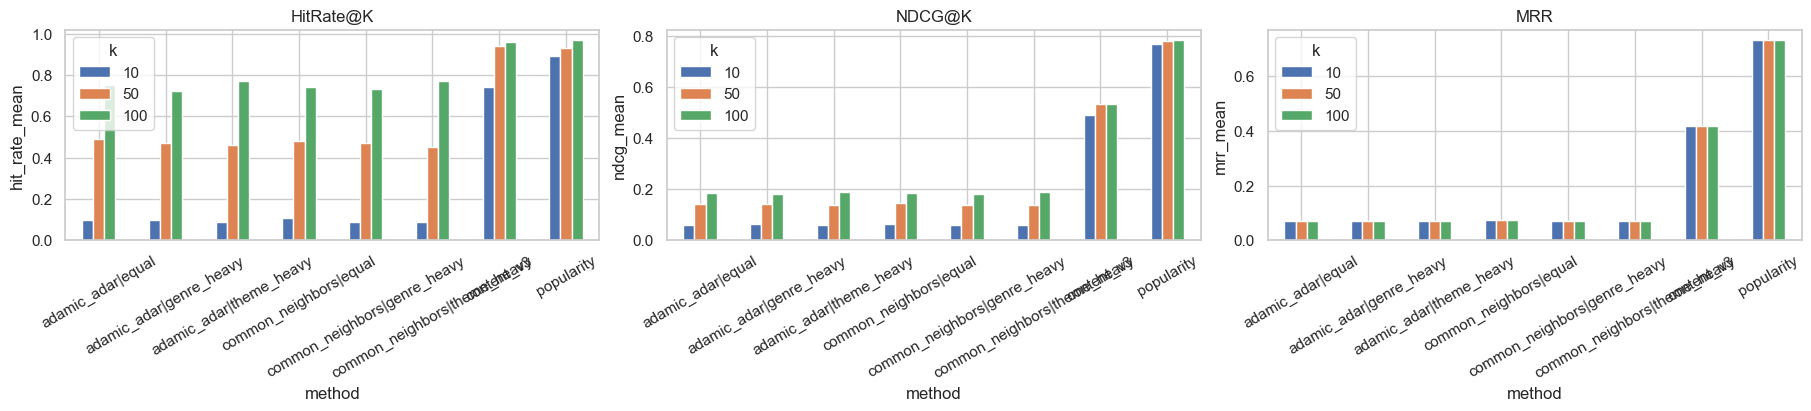

In [87]:
# summarize the stage 2 results
# this is the leaderboard view before moving on to embeddings

if eval_results.empty:
    print('No results to summarize.')
else:
    summary = (
        eval_results
        .groupby(['method', 'k'])
        .agg(
            users=('user_id', 'nunique'),
            seeds=('seed', 'nunique'),
            candidate_size_mean=('candidate_size', 'mean'),
            hit_rate_mean=('hit_rate_at_k', 'mean'),
            precision_mean=('precision_at_k', 'mean'),
            recall_mean=('recall_at_k', 'mean'),
            ndcg_mean=('ndcg_at_k', 'mean'),
            mrr_mean=('mrr', 'mean'),
            first_hit_rank_mean=('first_hit_rank', 'mean'),
            first_hit_rank_median=('first_hit_rank', 'median'),
        )
        .reset_index()
        .sort_values(['k', 'ndcg_mean'], ascending=[True, False])
    )

    display(summary)

    best_rows = (
        summary
        .sort_values(['k', 'ndcg_mean'], ascending=[True, False])
        .groupby('k', as_index=False)
        .head(3)
    )
    print('Top methods by NDCG@K:')
    display(best_rows[['k', 'method', 'ndcg_mean', 'hit_rate_mean', 'mrr_mean']])

    import matplotlib.pyplot as plt

    k_focus = min(KS)
    plot_methods = (
        summary[summary['k'] == k_focus]
        .sort_values('ndcg_mean', ascending=False)
        .head(8)['method']
        .tolist()
    )
    plot_df = summary[summary['method'].isin(plot_methods)].copy()

    metric_specs = [
        ('hit_rate_mean', 'HitRate@K'),
        ('ndcg_mean', 'NDCG@K'),
        ('mrr_mean', 'MRR'),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)

    for ax, (metric, title) in zip(axes, metric_specs):
        pivot = plot_df.pivot(index='method', columns='k', values=metric)
        pivot.plot(kind='bar', ax=ax)
        ax.set_title(title)
        ax.set_xlabel('method')
        ax.set_ylabel(metric)
        ax.tick_params(axis='x', rotation=30)

    plt.show()

## Evaluation Follow-Up

Summarize the Stage 2 offline results before moving to embeddings.


# Stage 3: Node2Vec Graph Embeddings

Train a simple positive-interaction Node2Vec model and score it with the same offline evaluation setup.


In [88]:
# stage 3 imports
# these are the graph and similarity tools for the node2vec baseline

import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity

In [89]:
# build the stage 3 positives
# here i combine the positive interactions that will define the bipartite graph

ratings_positive = ratings_edges.loc[
    ratings_edges['rating'].fillna(0) >= 7,
    ['user_id', 'manga_id'],
].copy()

reading_positive = reading_edges.loc[
    reading_edges['status'].str.lower().isin(['plan to read', 'in progress']),
    ['user_id', 'manga_id'],
].copy()

positive_df = pd.concat([ratings_positive, reading_positive], ignore_index=True).dropna().drop_duplicates()
positive_df['user_id'] = positive_df['user_id'].astype(str).str.strip().str.lower()
positive_df['manga_id'] = positive_df['manga_id'].astype(str).str.strip()

print('positive_df shape:', positive_df.shape)
print('Unique users:', positive_df['user_id'].nunique())
print('Unique manga:', positive_df['manga_id'].nunique())
display(positive_df.head())

positive_df shape: (87, 2)
Unique users: 5
Unique manga: 58


,user_id,manga_id
0,isaacmeyer,801513ba-a712-498c-8f57-cae55b38cc92
1,isaacmeyer,b16f2554-9525-4f2a-bbe4-5b75b6605176
2,isaacmeyer,cfc3d743-bd89-48e2-991f-63e680cc4edf
3,isaacmeyer,dd8a907a-3850-4f95-ba03-ba201a8399e3
4,isaacmeyer,192aa767-2479-42c1-9780-8d65a2efd36a


In [ ]:
# stage 3 evaluation settings
# this picks the k values, seeds, and eligible users for the node2vec tests

user_pos_counts = positive_df.groupby('user_id')['manga_id'].nunique()
eligible_users = user_pos_counts[user_pos_counts >= (HOLDOUT_PER_USER + 2)].index.tolist()

print('Eligible users:', len(eligible_users))
print('Example eligible users:', eligible_users[:10])

manga_catalog_ids = sorted(positive_df['manga_id'].dropna().astype(str).unique().tolist())
print('Catalog size:', len(manga_catalog_ids))

Eligible users: 5
Example eligible users: ['avreylavelle', 'bossitronio', 'chandler', 'isaacmeyer', 'jnance142']
Catalog size: 58


In [ ]:
# leave-k-out split for stage 3
# i use this to create train and held out positives for the embedding model

train_df, test_df = leave_k_out_split(
    positive_df,
    eligible_users,
    holdout_per_user=HOLDOUT_PER_USER,
    seed=42,
)

print('train_df:', train_df.shape)
print('test_df:', test_df.shape)
display(test_df.head())

train_df: (82, 2)
test_df: (5, 2)


,user_id,manga_id
0,avreylavelle,936f0ba5-ca65-4de4-99b1-528c02a4454d
1,bossitronio,bd6d0982-0091-4945-ad70-c028ed3c0917
2,chandler,75ee72ab-c6bf-4b87-badd-de839156934c
3,isaacmeyer,6a1d1cb1-ecd5-40d9-89ff-9d88e40b136b
4,jnance142,d1a9fdeb-f713-407f-960c-8326b586e6fd


In [ ]:
# candidate sampling helper
# this mixes held out positives with sampled negatives for ranking evaluation

def build_candidate_set_for_user(
    user_id,
    heldout_positive_ids,
    all_positive_df,
    manga_catalog_ids,
    NEGATIVE_SAMPLES=100,
    seed=42,
):
    rng = np.random.default_rng(seed)

    user_id = str(user_id).strip().lower()
    heldout_positive_ids = [str(x).strip() for x in heldout_positive_ids]

    seen_ids = set(
        all_positive_df.loc[
            all_positive_df['user_id'].astype(str).str.strip().str.lower() == user_id,
            'manga_id'
        ].astype(str)
    )

    candidate_negatives = [mid for mid in manga_catalog_ids if mid not in seen_ids]
    sample_size = min(NEGATIVE_SAMPLES, len(candidate_negatives))
    sampled_negatives = rng.choice(candidate_negatives, size=sample_size, replace=False).tolist() if sample_size > 0 else []

    candidate_ids = list(dict.fromkeys(heldout_positive_ids + sampled_negatives))

    candidate_df = pd.DataFrame(
        {
            'manga_id': candidate_ids,
            'label': [1 if mid in heldout_positive_ids else 0 for mid in candidate_ids],
        }
    )
    return candidate_df


example_user = test_df['user_id'].iloc[0]
example_pos = test_df.loc[test_df['user_id'] == example_user, 'manga_id'].astype(str).tolist()

candidate_df = build_candidate_set_for_user(
    user_id=example_user,
    heldout_positive_ids=example_pos,
    all_positive_df=positive_df,
    manga_catalog_ids=manga_catalog_ids,
    NEGATIVE_SAMPLES=NEGATIVE_SAMPLES,
    seed=42,
)

print(candidate_df.shape)
display(candidate_df.head())

(40, 2)


,manga_id,label
0,936f0ba5-ca65-4de4-99b1-528c02a4454d,1
1,eb2d1a45-d4e7-4e32-a171-b5b029c5b0cb,0
2,246f2c0c-4c50-4ef4-b292-c17f0f68a17c,0
3,19854049-66cb-4af6-b663-0aecdb6105a9,0
4,279c2494-8f85-4e5b-8bfb-a3223441fd13,0


In [93]:
# build the bipartite graph
# this turns the positive interactions into the user manga graph for node2vec

stage3_edges = positive_df.copy()


def build_stage3_bipartite_graph(train_df):
    G = nx.Graph()

    for row in train_df.itertuples(index=False):
        u = f'user::{row.user_id}'
        m = f'manga::{row.manga_id}'

        G.add_node(u, node_type='user')
        G.add_node(m, node_type='manga')
        G.add_edge(u, m, edge_type='positive_interaction', weight=1.0)

    return G


G_full = build_stage3_bipartite_graph(stage3_edges)

print('Graph nodes:', G_full.number_of_nodes())
print('Graph edges:', G_full.number_of_edges())

node_type_counts = pd.Series(
    [G_full.nodes[n].get('node_type', 'unknown') for n in G_full.nodes()]
).value_counts()

display(node_type_counts.rename_axis('node_type').reset_index(name='count'))

Graph nodes: 63
Graph edges: 87


,node_type,count
0,manga,58
1,user,5


In [94]:
# train the node2vec model
# this fits the embedding model and gives a quick similarity check

from node2vec import Node2Vec


def train_node2vec_model(
    G,
    dimensions=64,
    walk_length=20,
    num_walks=50,
    window=10,
    workers=2,
    p=1.0,
    q=1.0,
    seed=42,
):
    n2v = Node2Vec(
        G,
        dimensions=dimensions,
        walk_length=walk_length,
        num_walks=num_walks,
        workers=workers,
        p=p,
        q=q,
        seed=seed,
        weight_key='weight',
        quiet=True,
    )

    model = n2v.fit(
        window=window,
        min_count=1,
        batch_words=128,
    )
    return model


n2v_model_full = train_node2vec_model(G_full)

sample_manga_node = next(n for n in G_full.nodes() if G_full.nodes[n]['node_type'] == 'manga')
print('Sample manga node:', sample_manga_node)
print(n2v_model_full.wv.most_similar(sample_manga_node, topn=5))

Sample manga node: manga::801513ba-a712-498c-8f57-cae55b38cc92
[('manga::dd8a907a-3850-4f95-ba03-ba201a8399e3', 0.9785485863685608), ('manga::c52b2ce3-7f95-469c-96b0-479524fb7a1a', 0.93173748254776), ('manga::df3f7834-a65b-4d2c-9388-045c9ec03a35', 0.9198840856552124), ('manga::32d76d19-8a05-4db0-9fc2-e0b0648fe9d0', 0.9185340404510498), ('manga::62040a44-0935-46b7-a691-5ae5833af0ae', 0.9024861454963684)]


In [95]:
# stage 3 recommender
# this ranks candidate manga by cosine similarity to the user node embedding

def stage3_node2vec_recommend(
    model,
    train_df,
    user_id,
    candidate_manga_ids,
    top_k=20,
):
    user_node = f"user::{str(user_id).strip().lower()}"

    if user_node not in model.wv:
        return pd.DataFrame(columns=["manga_id", "score"])

    seen = set(
        train_df.loc[
            train_df["user_id"].astype(str).str.strip().str.lower() == str(user_id).strip().lower(),
            "manga_id"
        ].astype(str)
    )

    manga_nodes = []
    manga_ids = []

    for mid in candidate_manga_ids:
        mid = str(mid).strip()
        if mid in seen:
            continue

        node = f"manga::{mid}"
        if node in model.wv:
            manga_nodes.append(node)
            manga_ids.append(mid)

    if not manga_nodes:
        return pd.DataFrame(columns=["manga_id", "score"])

    user_vec = model.wv[user_node].reshape(1, -1)
    manga_vecs = np.array([model.wv[node] for node in manga_nodes])

    scores = cosine_similarity(user_vec, manga_vecs)[0]

    recs = pd.DataFrame({
        "manga_id": manga_ids,
        "score": scores,
    }).sort_values("score", ascending=False).head(top_k)

    return recs.reset_index(drop=True)


example_user = stage3_edges["user_id"].iloc[0]
candidate_pool = stage3_edges["manga_id"].drop_duplicates().tolist()[:500]

display(stage3_node2vec_recommend(
    n2v_model_full,
    stage3_edges,
    example_user,
    candidate_pool,
    top_k=10,
))

,manga_id,score
0,d90ea6cb-7bc3-4d80-8af0-28557e6c4e17,0.500798
1,a77742b1-befd-49a4-bff5-1ad4e6b0ef7b,0.490230
2,d8a959f7-648e-4c8d-8f23-f1f3f8e129f3,0.454753
3,d9e30523-9d65-469e-92a2-302995770950,0.438895
4,46e9cae5-4407-4576-9b9e-4c517ae9298e,0.422491
5,de900fd3-c94c-4148-bbcb-ca56eaeb57a4,0.421262
6,077a3fed-1634-424f-be7a-9a96b7f07b78,0.394631
7,9d3d3403-1a87-4737-9803-bc3d99db1424,0.387396
8,1044287a-73df-48d0-b0b2-5327f32dd651,0.381782
9,75ee72ab-c6bf-4b87-badd-de839156934c,0.348631


In [ ]:
# evaluate node2vec for one seed
# this runs the full split, train, recommend, and metric pass once

def evaluate_node2vec_one_seed(
    seed,
    dimensions=64,
    walk_length=20,
    num_walks=50,
    window=10,
    p=1.0,
    q=1.0,
):
    train_df, test_df = leave_k_out_split(
        positive_df,
        eligible_users,
        holdout_per_user=HOLDOUT_PER_USER,
        seed=seed,
    )

    G_train = build_stage3_bipartite_graph(train_df)
    model = train_node2vec_model(
        G_train,
        dimensions=dimensions,
        walk_length=walk_length,
        num_walks=num_walks,
        window=window,
        p=p,
        q=q,
        seed=seed,
    )

    rows = []

    for user_id in sorted(test_df['user_id'].unique()):
        user_test = test_df.loc[test_df['user_id'] == user_id]
        heldout_positive_ids = user_test['manga_id'].astype(str).tolist()

        candidate_df = build_candidate_set_for_user(
            user_id=user_id,
            heldout_positive_ids=heldout_positive_ids,
            all_positive_df=positive_df,
            manga_catalog_ids=manga_catalog_ids,
            NEGATIVE_SAMPLES=NEGATIVE_SAMPLES,
            seed=seed,
        )

        candidate_ids = candidate_df['manga_id'].astype(str).tolist()

        recs = stage3_node2vec_recommend(
            model=model,
            train_df=train_df,
            user_id=user_id,
            candidate_manga_ids=candidate_ids,
            top_k=max(KS),
        )

        ranked_ids = recs['manga_id'].astype(str).tolist()
        relevant_ids = set(heldout_positive_ids)

        for k in KS:
            topk = ranked_ids[:k]

            hits = [1 if mid in relevant_ids else 0 for mid in topk]
            hitrate = float(any(hits))
            precision = sum(hits) / k if k > 0 else 0.0
            recall = sum(hits) / len(relevant_ids) if relevant_ids else 0.0

            dcg = sum(hit / np.log2(idx + 2) for idx, hit in enumerate(hits))
            ideal_hits = [1] * min(len(relevant_ids), k)
            idcg = sum(hit / np.log2(idx + 2) for idx, hit in enumerate(ideal_hits))
            ndcg = dcg / idcg if idcg > 0 else 0.0

            rr = 0.0
            for idx, mid in enumerate(topk):
                if mid in relevant_ids:
                    rr = 1.0 / (idx + 1)
                    break

            rows.append(
                {
                    'seed': seed,
                    'user_id': user_id,
                    'method': 'node2vec',
                    'k': k,
                    'precision': precision,
                    'recall': recall,
                    'ndcg': ndcg,
                    'hitrate': hitrate,
                    'mrr': rr,
                    'candidate_size': len(candidate_ids),
                    'heldout_count': len(relevant_ids),
                    'dimensions': dimensions,
                    'walk_length': walk_length,
                    'num_walks': num_walks,
                    'window': window,
                    'p': p,
                    'q': q,
                }
            )

    return pd.DataFrame(rows)

In [ ]:
# run the node2vec experiments
# this loops over the evaluation seeds and collects all of the raw results

stage3_results = []

for seed in SEEDS:
    print(f"Running Node2Vec evaluation for seed={seed} ...")
    df_seed = evaluate_node2vec_one_seed(
        seed=seed,
        dimensions=64,
        walk_length=20,
        num_walks=50,
        window=10,
        p=1.0,
        q=1.0,
    )
    stage3_results.append(df_seed)

stage3_results = pd.concat(stage3_results, ignore_index=True)

print("Stage 3 results shape:", stage3_results.shape)
display(stage3_results.head())

Running Node2Vec evaluation for seed=7 ...
Running Node2Vec evaluation for seed=21 ...
Running Node2Vec evaluation for seed=42 ...
Stage 3 results shape: (45, 17)


,seed,user_id,method,k,precision,recall,ndcg,hitrate,mrr,candidate_size,heldout_count,dimensions,walk_length,num_walks,window,p,q
0,7,avreylavelle,node2vec,10,0.00,0.0,0.000000,0.0,0.000000,40,1,64,20,50,10,1.0,1.0
1,7,avreylavelle,node2vec,50,0.02,1.0,0.250000,1.0,0.066667,40,1,64,20,50,10,1.0,1.0
2,7,avreylavelle,node2vec,100,0.01,1.0,0.250000,1.0,0.066667,40,1,64,20,50,10,1.0,1.0
3,7,bossitronio,node2vec,10,0.00,0.0,0.000000,0.0,0.000000,41,1,64,20,50,10,1.0,1.0
4,7,bossitronio,node2vec,50,0.02,1.0,0.255958,1.0,0.071429,41,1,64,20,50,10,1.0,1.0


In [98]:
# stage 3 summary table
# this averages the node2vec metrics across users and seeds

stage3_summary = (
    stage3_results
    .groupby(["method", "k"])
    .agg(
        users=("user_id", "nunique"),
        seeds=("seed", "nunique"),
        precision_mean=("precision", "mean"),
        recall_mean=("recall", "mean"),
        ndcg_mean=("ndcg", "mean"),
        hitrate_mean=("hitrate", "mean"),
        mrr_mean=("mrr", "mean"),
    )
    .reset_index()
)

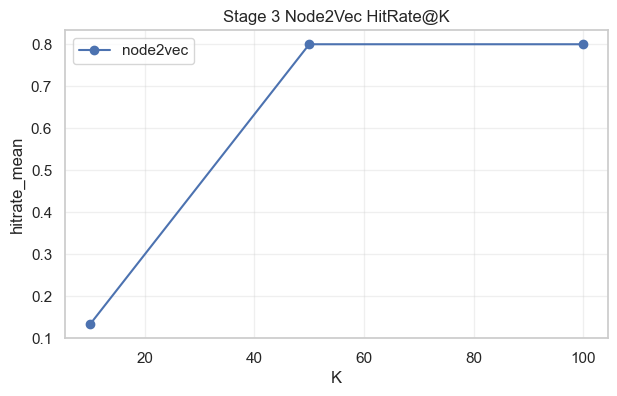

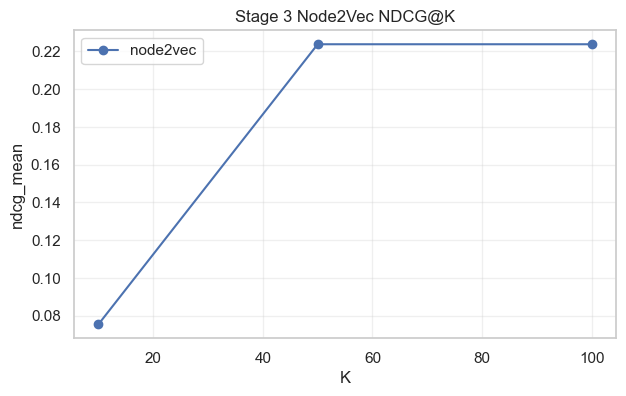

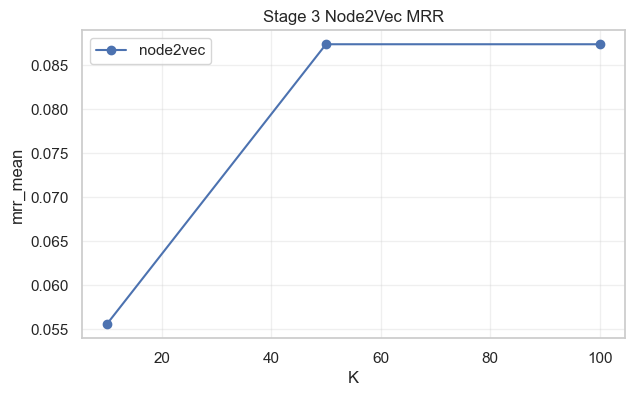

In [99]:
# plot the stage 3 metrics
# these charts make the node2vec results easier to compare across k

import matplotlib.pyplot as plt

def plot_metric(df, metric, title):
    plt.figure(figsize=(7, 4))
    subset = df[df["method"] == "node2vec"].sort_values("k")
    plt.plot(subset["k"], subset[metric], marker="o", label="node2vec")
    plt.xlabel("K")
    plt.ylabel(metric)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_metric(stage3_summary, "hitrate_mean", "Stage 3 Node2Vec HitRate@K")
plot_metric(stage3_summary, "ndcg_mean", "Stage 3 Node2Vec NDCG@K")
plot_metric(stage3_summary, "mrr_mean", "Stage 3 Node2Vec MRR")

In [100]:
# save the stage 3 outputs
# i write the raw and summary files out so i can reuse them later

OUT_DIR = REPO_ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

stage3_results.to_csv(OUT_DIR / "stage3_node2vec_results_raw.csv", index=False)
stage3_summary.to_csv(OUT_DIR / "stage3_node2vec_summary.csv", index=False)

print("Saved Stage 3 outputs to:", OUT_DIR)

Saved Stage 3 outputs to: C:\Users\avrey\dev\shelf\outputs


In [101]:
# final stage 3 preview
# this is just the last check of the summary table at the end

print("Stage 3 summary shape:", stage3_summary.shape)
display(stage3_summary)

Stage 3 summary shape: (3, 9)


,method,k,users,seeds,precision_mean,recall_mean,ndcg_mean,hitrate_mean,mrr_mean
0,node2vec,10,5,3,0.013333,0.133333,0.075395,0.133333,0.055556
1,node2vec,50,5,3,0.016000,0.800000,0.223837,0.800000,0.087369
2,node2vec,100,5,3,0.008000,0.800000,0.223837,0.800000,0.087369
